# 07 — Final evaluation on the held-out test set

The only place the test set is scored. Every earlier choice was made on cross-validation over the training split.

**Pipeline module:** `src/final_evaluation.py`

*Every number and figure below was produced by the pipeline in `src/`. This
notebook reads those results; it does not re-implement them.*

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd
from IPython.display import Image, display

TABLES = ROOT / "results" / "tables"
FIGURES = ROOT / "results" / "figures"

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

def table(name, **kw):
    """Read one of the pipeline's result tables."""
    return pd.read_csv(TABLES / name, **kw)

def figure(name):
    """Display one of the pipeline's figures."""
    return Image(filename=str(FIGURES / name))

print(f"project root: {ROOT}")

project root: C:\Users\babu\OneDrive\Desktop\ML Project


## The final model

XGBoost with default settings, refit on all 320,032 training rows, scored once on the
sealed 80,008-row test set.

Chosen on evidence rather than F1 alone: it leads binary cross-validation at
0.99678 ± 0.00059 and predicts 80,008 flows in 0.11 seconds against SVM's 56.8. For a
system watching live traffic, prediction latency is a requirement, not a tiebreak. On
the multi-class task the three tree models are statistically indistinguishable, so
cost and consistency decide it.

In [2]:
final = table("final_evaluation.csv")
final.round(6)

,settings,experiment,accuracy,precision,recall,f1,roc_auc,pr_auc,fit_seconds,predict_seconds
0,default,A (binary),0.998975,0.995976,0.998021,0.996997,0.999969,0.999843,4.47,0.11
1,tuned,A (binary),0.998975,0.996049,0.997947,0.996997,0.999971,0.999852,3.36,0.08
2,default,B (multi),0.998813,0.977810,0.944294,0.958281,0.999973,0.987474,37.90,0.66
3,tuned,B (multi),0.998713,0.982266,0.939033,0.957744,0.999974,0.986039,59.12,0.85


### Six decimal places, deliberately

At four, ROC-AUC reads `1.0000` — a perfect score. That is impossible here: three
flows carry identical features with conflicting labels, so no model can be right about
both. **0.999969** is the true figure and the defensible one.

### Cross-validation predicted this to four decimals

| | Binary F1 |
|---|---|
| Cross-validation estimate (training data only) | 0.99678 |
| Held-out test set (never seen) | 0.996997 |

A gap of 0.0002. That agreement is the real result — it is the evidence that the
deduplication worked, the stratified split held, feature selection never saw the test
data, and the model generalises.

### The tuned model lost

Multi-class F1 fell from 0.958281 to 0.957744 with tuned settings, and fit time rose
from 37.9s to 59.1s. Notebook 06 predicted exactly this. The defaults ship.

## Confusion matrices

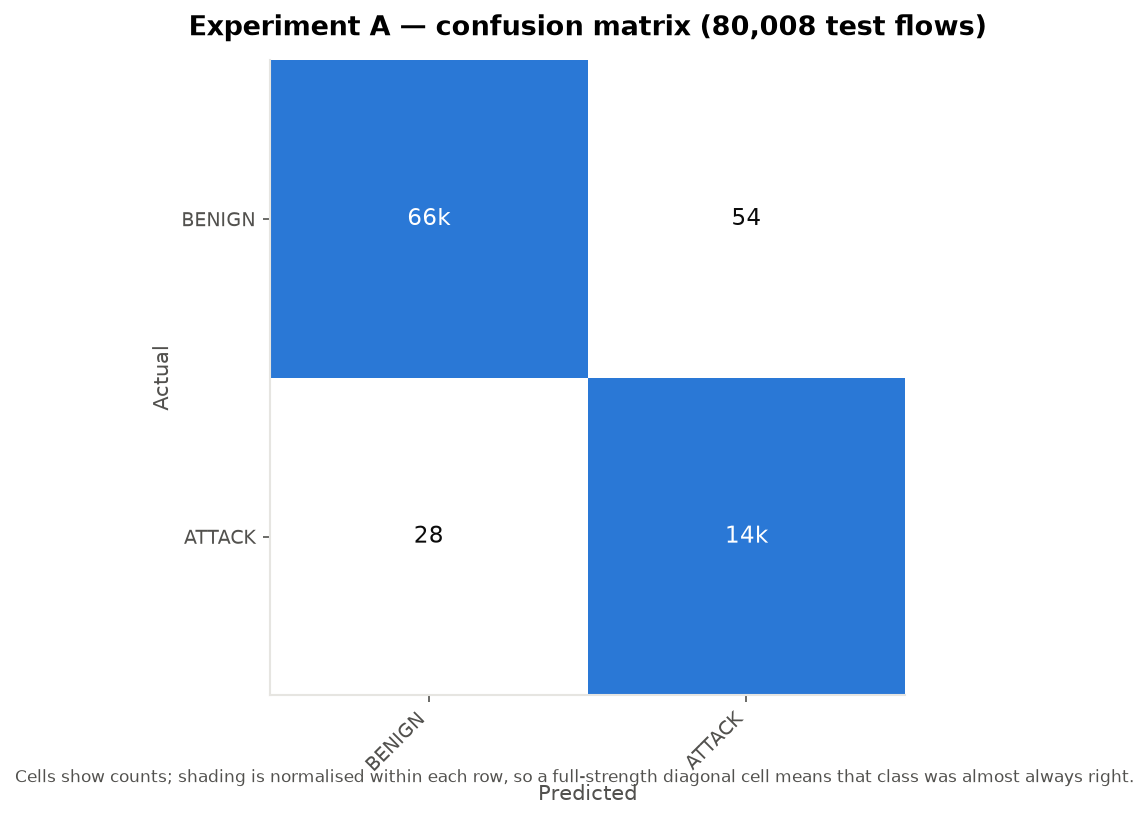

In [3]:
figure("14_confusion_binary.png")

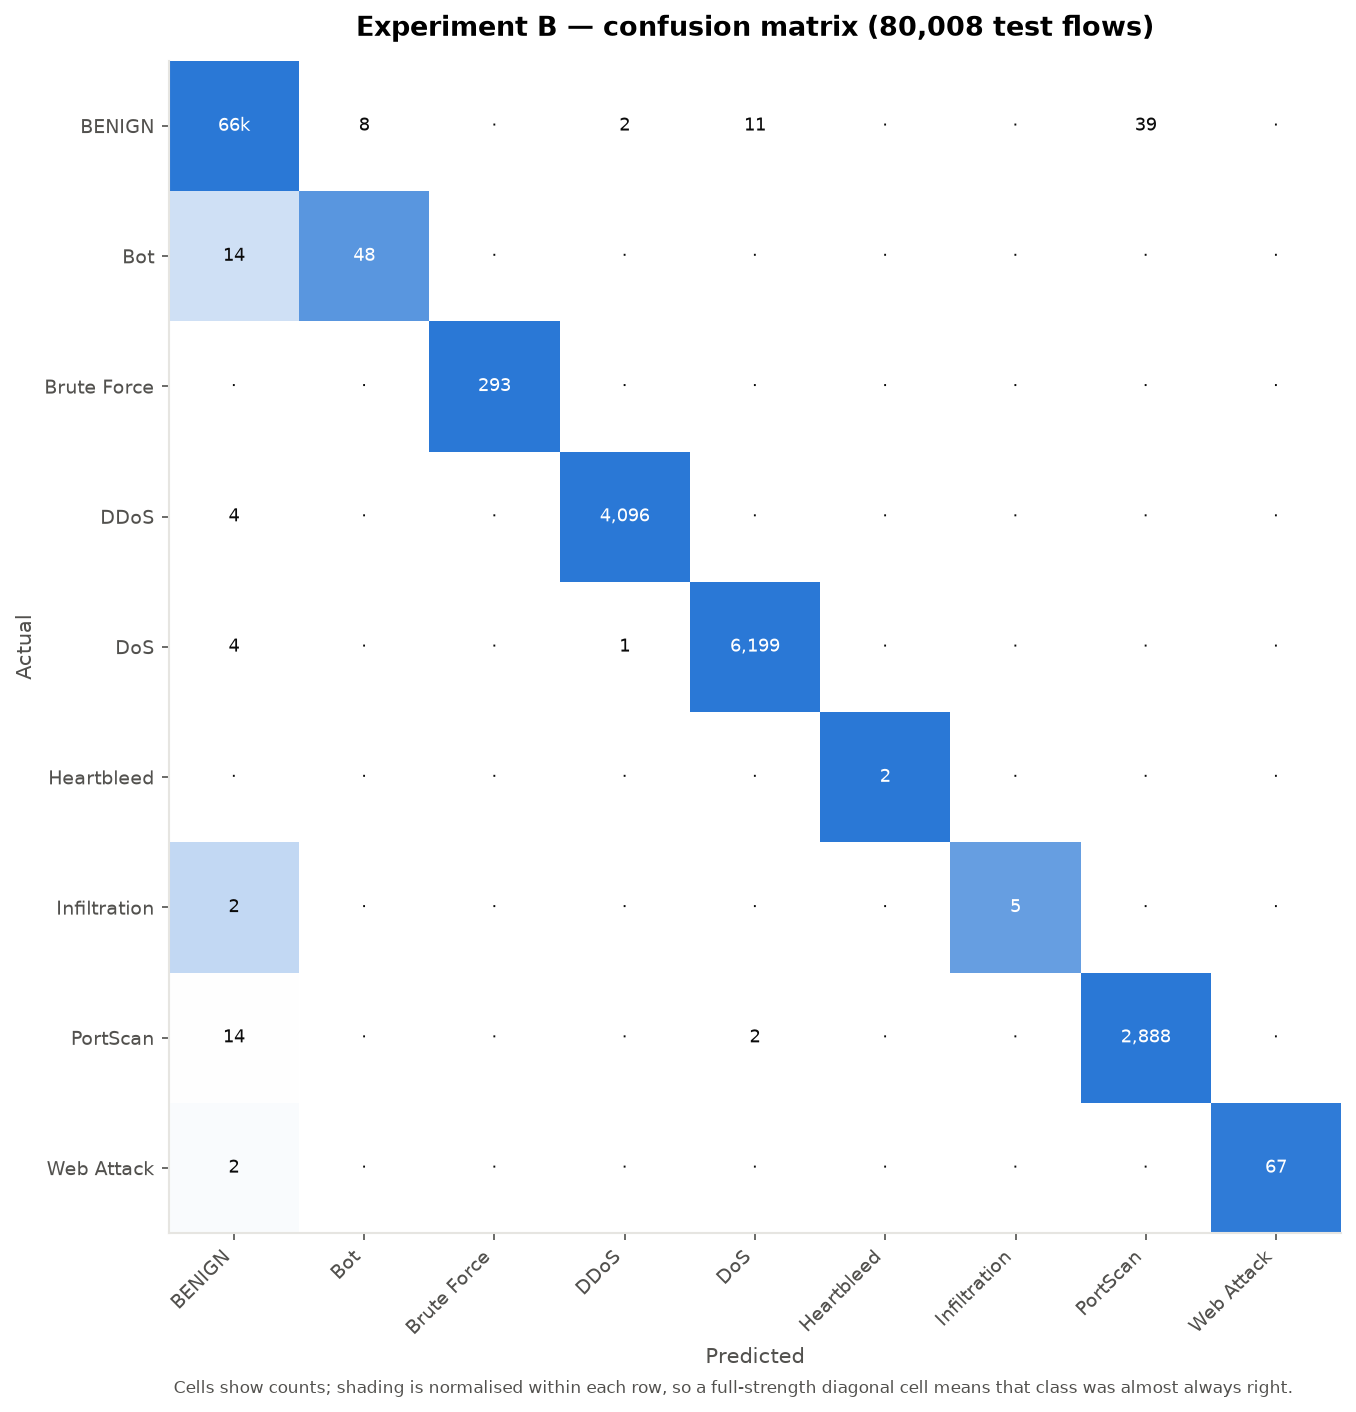

In [4]:
figure("15_confusion_multi.png")

Nearly every error is a confusion with BENIGN in one direction or the other — 39
benign flows called PortScan, 14 Bot and 14 PortScan flows called benign. The model
almost never mistakes one attack type for another. **The hard problem is the benign
boundary, not telling attacks apart.**

## ROC and precision-recall curves

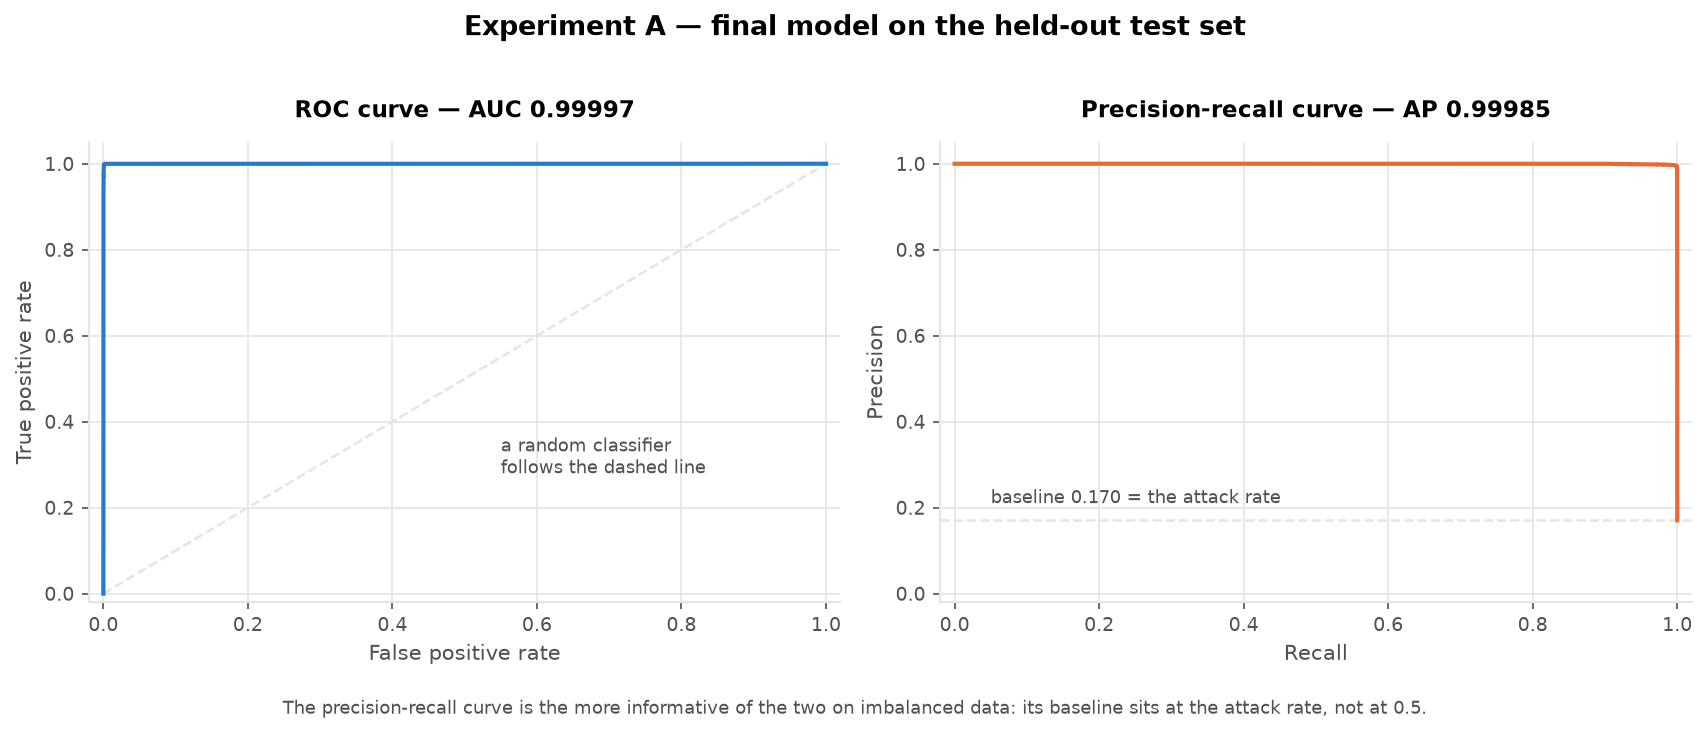

In [5]:
figure("16_roc_pr_curves.png")

The precision-recall curve is the more informative of the two on imbalanced data: its
baseline sits at the attack rate, not at 0.5.

## Per-class performance

In [6]:
per_class = table("final_per_class_report.csv", index_col=0)
per_class.round(4)

,precision,recall,f1-score,support
BENIGN,0.9994,0.9991,0.9992,66367.0
Bot,0.8571,0.7742,0.8136,62.0
Brute Force,1.0000,1.0000,1.0000,293.0
DDoS,0.9993,0.9990,0.9991,4100.0
DoS,0.9979,0.9992,0.9986,6204.0
Heartbleed,1.0000,1.0000,1.0000,2.0
Infiltration,1.0000,0.7143,0.8333,7.0
PortScan,0.9867,0.9945,0.9906,2904.0
Web Attack,1.0000,0.9710,0.9853,69.0


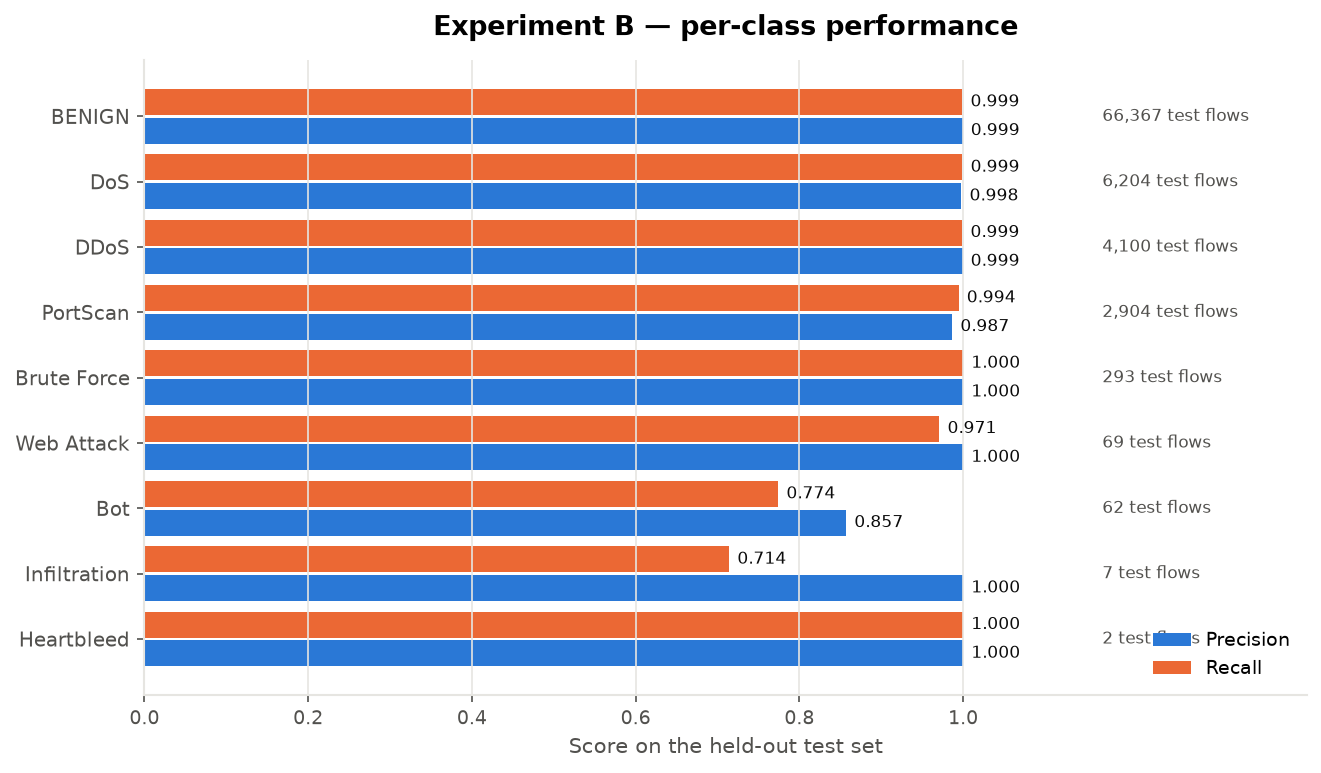

In [7]:
figure("17_final_per_class.png")

## Honest limitations

- **Infiltration: precision 1.0000, recall 0.7143.** When the model says Infiltration
  it is always right, but it catches only 5 of 7. That is the dangerous direction of
  error — an attacker already inside the network, behaving like an ordinary user,
  walking past the detector.
- **Bot is the weakest class at 0.8136**, exactly as cross-validation predicted from
  training data alone, before the test set was ever opened.
- **Three flows carry conflicting labels**, so a perfect score is impossible.
- **This is 2017 traffic.** A model trained on it should not be assumed to detect
  attacks invented since.